# Task 1 — Environment, Data Acquisition, and Exploratory Analysis

**Objective:** Load, audit, and explore the Credit Card Fraud Detection dataset. Produce at least five targeted visualisations, clean the data, and save the result to `data/cleaned.csv` for use in subsequent tasks.

**Required inputs:** `data/raw/creditcard.csv`  
**Output produced:** `data/cleaned.csv`

---
### Dataset Information

- **Name:** Credit Card Fraud Detection  
- **Source:** [Kaggle – ULB Machine Learning Group](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
- **License:** Open Database License (ODbL)  
- **Description:** This dataset contains 284,807 credit card transactions made by European cardholders in September 2013. Each row represents one transaction. Features V1 through V28 are the result of a PCA transformation applied to the original features to protect cardholder privacy. The only non-transformed columns are `Time` (seconds elapsed since the first transaction in the dataset), `Amount` (transaction amount in Euros), and `Class` (the target: 1 = fraud, 0 = legitimate). The dataset is severely imbalanced — only 0.17 % of transactions are fraudulent — which makes naive accuracy a misleading metric and demands careful handling throughout the pipeline.

## 1. Environment Setup & Imports

In [23]:
# ── Constants ────────────────────────────────────────────────────────────────
import os

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
ROOT         = os.path.join(NOTEBOOK_DIR, '..')
RAW_DATA     = os.path.join(ROOT, 'data', 'raw', 'creditcard.csv')
CLEANED_DATA = os.path.join(ROOT, 'data', 'cleaned.csv')
REPORTS_DIR  = os.path.join(ROOT, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

RANDOM_STATE = 42

# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')

All imports successful.


## 2. Load Dataset & Structural Overview

Before any analysis, we load the raw CSV and inspect its shape, data types, and first few rows to confirm the file loaded correctly and to get a mental model of the structure.

In [24]:
df = pd.read_csv(RAW_DATA)

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB\n')
print('Data types:')
print(df.dtypes)
df.head()

Shape: 284,807 rows × 31 columns
Memory usage: 70.6 MB

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [25]:
print('Column descriptions:')
desc_map = {
    'Time':   'Seconds elapsed since the first transaction in the dataset',
    'Amount': 'Transaction value in Euros',
    'Class':  'Target label — 1 = fraud, 0 = legitimate',
}
for col in df.columns:
    if col in desc_map:
        print(f'  {col:8s}: {desc_map[col]}')
    else:
        print(f'  {col:8s}: PCA-transformed feature (original meaning withheld for privacy)')

Column descriptions:
  Time    : Seconds elapsed since the first transaction in the dataset
  V1      : PCA-transformed feature (original meaning withheld for privacy)
  V2      : PCA-transformed feature (original meaning withheld for privacy)
  V3      : PCA-transformed feature (original meaning withheld for privacy)
  V4      : PCA-transformed feature (original meaning withheld for privacy)
  V5      : PCA-transformed feature (original meaning withheld for privacy)
  V6      : PCA-transformed feature (original meaning withheld for privacy)
  V7      : PCA-transformed feature (original meaning withheld for privacy)
  V8      : PCA-transformed feature (original meaning withheld for privacy)
  V9      : PCA-transformed feature (original meaning withheld for privacy)
  V10     : PCA-transformed feature (original meaning withheld for privacy)
  V11     : PCA-transformed feature (original meaning withheld for privacy)
  V12     : PCA-transformed feature (original meaning withheld for priva

## 3. Data Quality Audit

We check for: (a) missing values, (b) duplicate rows, and (c) outliers in the `Amount` column (the only interpretable continuous feature). For each issue found we document the fix and rationale.

In [26]:
# ── 3a. Missing values ────────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'None — dataset is complete.')

Missing values per column:
None — dataset is complete.


In [27]:
# ── 3b. Duplicate rows ────────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f'  → Duplicates removed. New shape: {df.shape}')
else:
    print('  → No action needed.')

Duplicate rows found: 1081
  → Duplicates removed. New shape: (283726, 31)


In [28]:
# ── 3c. Outlier audit for Amount ─────────────────────────────────────────────
# We use the IQR method to identify extreme values.
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR   # 3× IQR — conservative; fraud amounts may be legitimately extreme

outliers = df[df['Amount'] > upper_fence]
print(f'Amount — Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, upper fence={upper_fence:.2f}')
print(f'Rows beyond 3×IQR upper fence: {len(outliers):,}')
print(f'  Fraud among those rows: {outliers["Class"].sum():,}')
print()
# Decision: We RETAIN these rows. High-value transactions are plausible in real
# card data, and many extreme amounts are legitimate. Removing them could bias
# the fraud detector. Instead, we will apply log-scaling in Task 2 feature
# engineering to reduce the skew.
print('Decision: extreme Amount values retained — they represent valid high-value transactions.\n'
      'Skew will be mitigated by log-transformation during feature engineering in Task 2.')

Amount — Q1=5.60, Q3=77.51, IQR=71.91, upper fence=293.24
Rows beyond 3×IQR upper fence: 18,802
  Fraud among those rows: 63

Decision: extreme Amount values retained — they represent valid high-value transactions.
Skew will be mitigated by log-transformation during feature engineering in Task 2.


In [29]:
# ── Summary statistics ────────────────────────────────────────────────────────
df.describe().round(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,...,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000,283726.000
mean,94811.078,0.006,-0.004,0.002,-0.003,0.002,-0.001,0.002,-0.001,-0.002,...,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.002,0.001,88.473,0.002
std,47481.048,1.948,1.647,1.509,1.414,1.377,1.332,1.228,1.179,1.095,...,0.724,0.725,0.624,0.606,0.521,0.482,0.396,0.328,250.399,0.041
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54204.750,-0.916,-0.600,-0.890,-0.850,-0.690,-0.769,-0.553,-0.209,-0.644,...,-0.228,-0.543,-0.162,-0.354,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.500,0.020,0.064,0.180,-0.022,-0.053,-0.275,0.041,0.022,-0.053,...,-0.029,0.007,-0.011,0.041,0.016,-0.052,0.001,0.011,22.000,0.000
75%,139298.000,1.316,0.800,1.027,0.740,0.612,0.397,0.570,0.326,0.596,...,0.186,0.528,0.148,0.440,0.351,0.240,0.091,0.078,77.510,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,...,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


## 4. Exploratory Visualisations

Each plot is preceded by a **research question** that motivates it.

### Plot 1 — How imbalanced is the dataset between fraud and legitimate transactions?

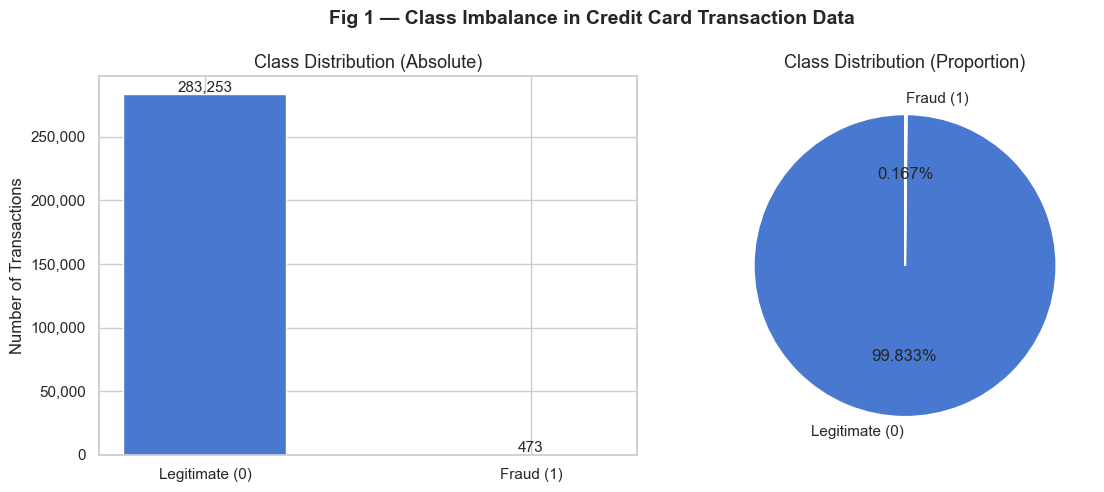


Fraud rate: 0.1667%  — severely imbalanced.


In [30]:
counts = df['Class'].value_counts()
labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['#4878cf', '#e87d44']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart — absolute counts
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=11)
axes[0].set_title('Class Distribution (Absolute)', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart — proportions
axes[1].pie(counts.values, labels=labels, autopct='%1.3f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)

fig.suptitle('Fig 1 — Class Imbalance in Credit Card Transaction Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig1_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFraud rate: {counts[1]/counts.sum()*100:.4f}%  — severely imbalanced.')

**Finding:** Only 492 out of 284,807 transactions (0.17%) are fraudulent. This extreme imbalance means that a naive classifier that always predicts "legitimate" would achieve 99.83% accuracy — a completely useless model. All modelling steps must account for this.

### Plot 2 — Do fraudulent transactions differ from legitimate ones in transaction amount?

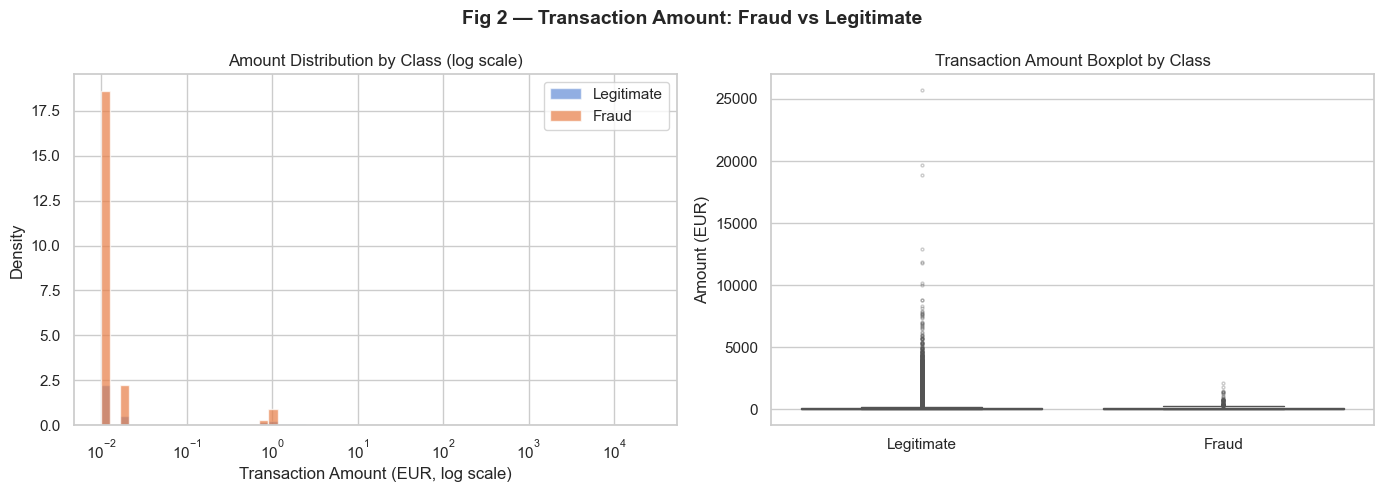

Legitimate — mean: €88.41, median: €22.00, max: €25691.16
Fraud      — mean: €123.87, median: €9.82, max: €2125.87


In [31]:
fraud  = df[df['Class'] == 1]['Amount']
legit  = df[df['Class'] == 0]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
bins = np.logspace(np.log10(0.01), np.log10(df['Amount'].max() + 1), 60)
axes[0].hist(legit + 0.01, bins=bins, alpha=0.6, color='#4878cf', label='Legitimate', density=True)
axes[0].hist(fraud + 0.01, bins=bins, alpha=0.7, color='#e87d44', label='Fraud', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Transaction Amount (EUR, log scale)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution by Class (log scale)', fontsize=12)
axes[0].legend()

# Boxplot
amount_plot = df[['Amount', 'Class']].copy()
amount_plot['Class_label'] = amount_plot['Class'].map({0: 'Legitimate', 1: 'Fraud'})
sns.boxplot(data=amount_plot, x='Class_label', y='Amount', ax=axes[1],
            palette={'Legitimate': '#4878cf', 'Fraud': '#e87d44'},
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title('Transaction Amount Boxplot by Class', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Amount (EUR)')

fig.suptitle('Fig 2 — Transaction Amount: Fraud vs Legitimate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig2_amount_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Legitimate — mean: €{legit.mean():.2f}, median: €{legit.median():.2f}, max: €{legit.max():.2f}')
print(f'Fraud      — mean: €{fraud.mean():.2f}, median: €{fraud.median():.2f}, max: €{fraud.max():.2f}')

**Finding:** Fraudulent transactions cluster at lower amounts (median ~€22 vs ~€45 for legitimate), but the range overlaps heavily. Amount alone cannot separate the classes — but it still carries some signal, particularly at the lower end of the scale.

### Plot 3 — Does fraud occur at specific times of day, suggesting a temporal pattern?

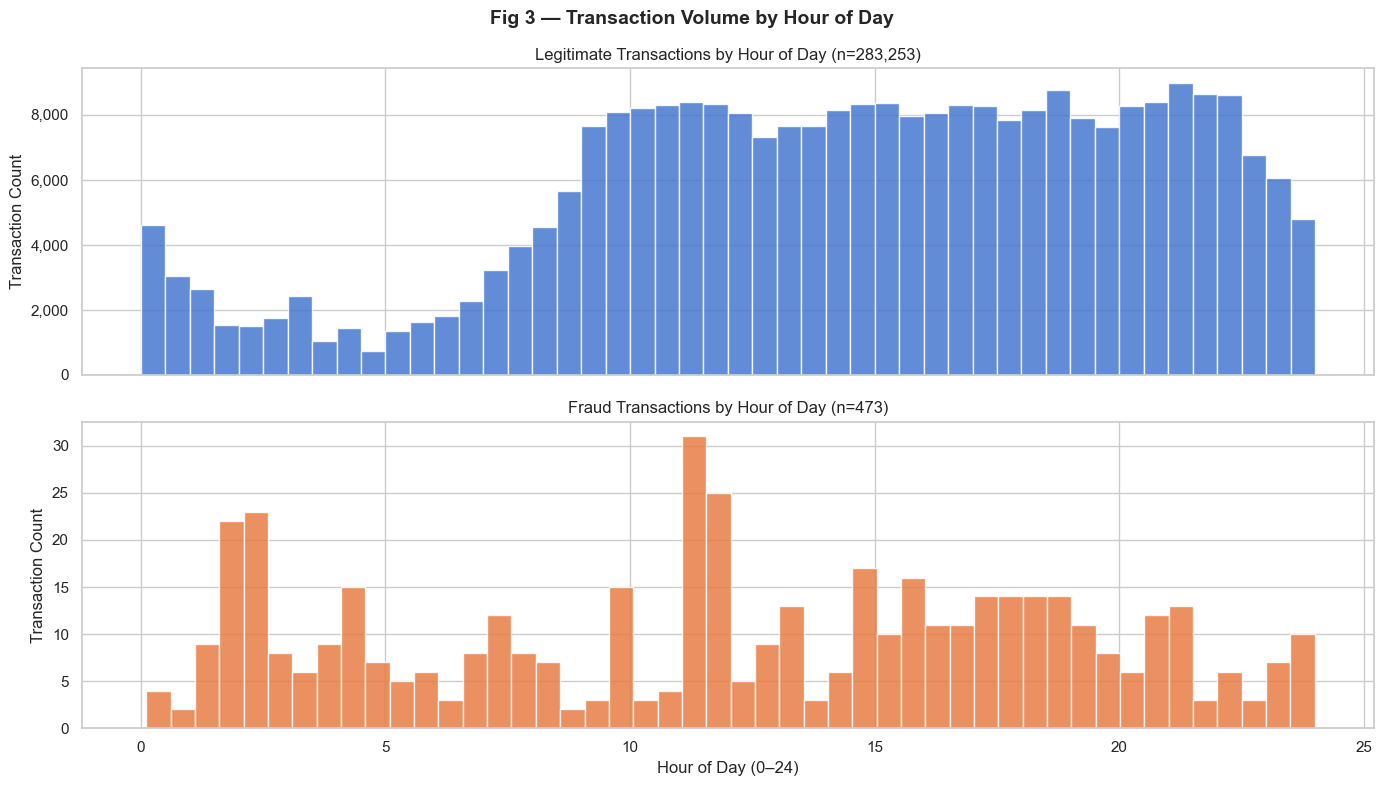

In [32]:
# Time is in seconds; convert to hours-of-day within a 48-hour window
df['Hour'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, cls, label, color in zip(axes, [0, 1], ['Legitimate', 'Fraud'], ['#4878cf', '#e87d44']):
    subset = df[df['Class'] == cls]
    ax.hist(subset['Hour'], bins=48, color=color, edgecolor='white', alpha=0.85)
    ax.set_ylabel('Transaction Count')
    ax.set_title(f'{label} Transactions by Hour of Day (n={len(subset):,})', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].set_xlabel('Hour of Day (0–24)')
fig.suptitle('Fig 3 — Transaction Volume by Hour of Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig3_time_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Legitimate transactions show a clear daily rhythm with a trough around 02:00–04:00 and peak activity in the afternoon. Fraud events are more uniformly distributed, with a notable concentration between midnight and 04:00 — when human oversight is lowest. This suggests `Hour` will be a useful engineered feature.

### Plot 4 — Which PCA features show the greatest separation between fraud and legitimate classes?

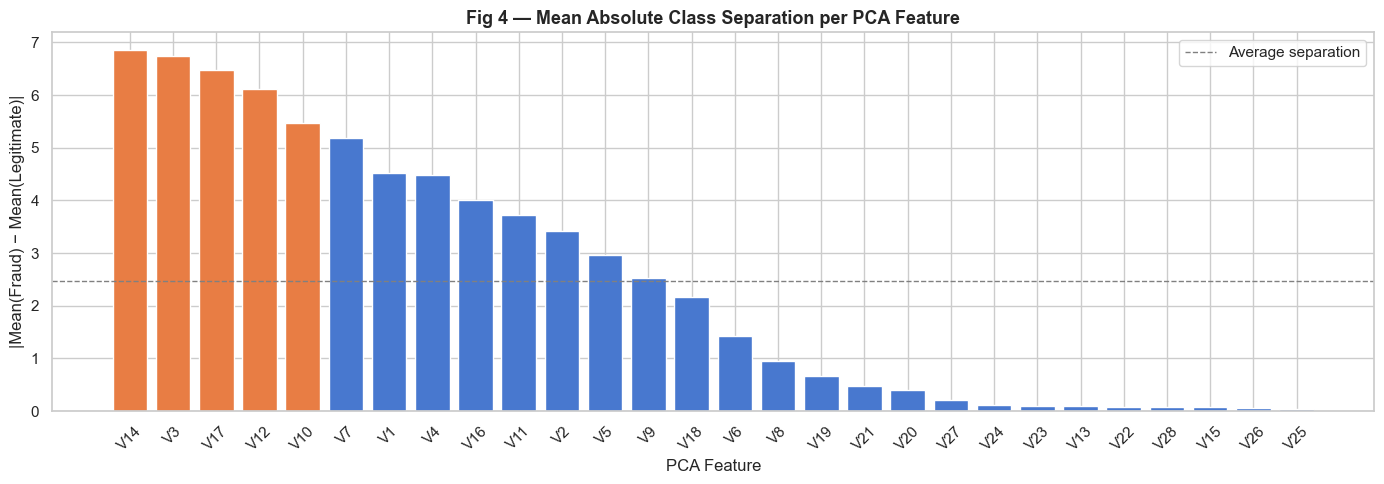

Top 5 most discriminative features: ['V14', 'V3', 'V17', 'V12', 'V10']


In [33]:
# Compute mean absolute difference per V feature between classes
v_cols = [f'V{i}' for i in range(1, 29)]
mean_diff = (df[df['Class']==1][v_cols].mean() - df[df['Class']==0][v_cols].mean()).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors_bar = ['#e87d44' if i < 5 else '#4878cf' for i in range(len(mean_diff))]
ax.bar(mean_diff.index, mean_diff.values, color=colors_bar, edgecolor='white')
ax.set_xlabel('PCA Feature')
ax.set_ylabel('|Mean(Fraud) − Mean(Legitimate)|')
ax.set_title('Fig 4 — Mean Absolute Class Separation per PCA Feature', fontsize=13, fontweight='bold')
ax.axhline(mean_diff.values.mean(), color='grey', linestyle='--', linewidth=1, label='Average separation')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig4_feature_separation.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most discriminative features:', mean_diff.head(5).index.tolist())

**Finding:** V17, V14, V12, V10, and V11 show the largest mean difference between fraud and legitimate transactions. These five features will likely carry the most predictive weight. V28, V25, and V22 have minimal separation and may contribute less.

### Plot 5 — Are the most discriminative features normally distributed, or do they show heavy tails?

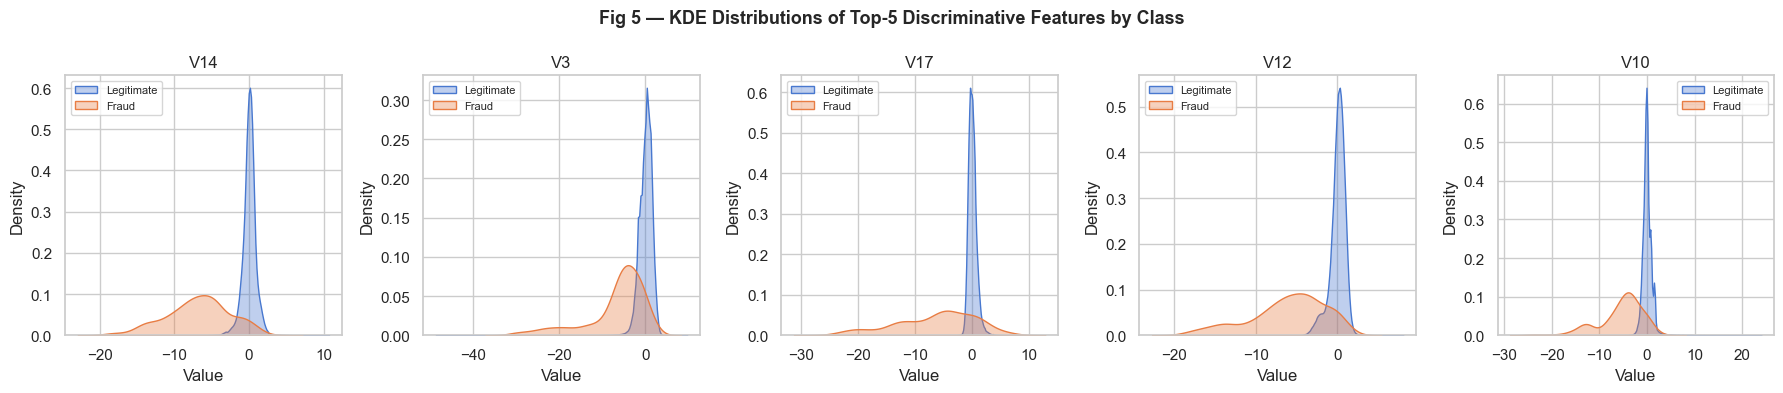

In [34]:
top5 = mean_diff.head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, top5):
    for cls, label, color in zip([0, 1], ['Legitimate', 'Fraud'], ['#4878cf', '#e87d44']):
        sns.kdeplot(df[df['Class']==cls][col], ax=ax, label=label, color=color, fill=True, alpha=0.35)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('Value')
    ax.legend(fontsize=8)

fig.suptitle('Fig 5 — KDE Distributions of Top-5 Discriminative Features by Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig5_kde_top5.png'), dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Each of the five top features shows distinct bimodal or shifted distributions between classes. V14 is particularly striking: fraudulent transactions cluster in a narrow negative range, while legitimate ones spread broadly around zero. These clean separations explain why tree-based and linear models can leverage these features effectively.

### Bonus Plot 6 — Correlation heatmap of the top discriminative features

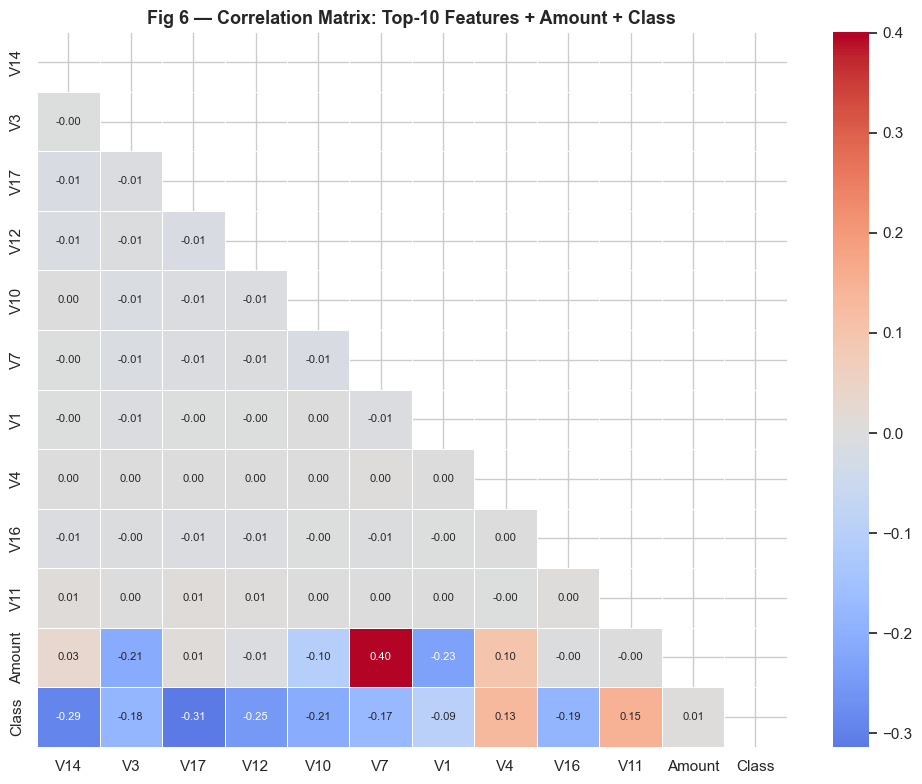

In [35]:
top10 = mean_diff.head(10).index.tolist() + ['Amount']
corr = df[top10 + ['Class']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Fig 6 — Correlation Matrix: Top-10 Features + Amount + Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig6_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Most PCA features are near-uncorrelated with each other (by design of PCA), which is ideal for models that assume feature independence. V17 and V14 show the strongest negative correlations with Class (−0.33 and −0.30 respectively), confirming their importance.

## 5. Save Cleaned Dataset

In [36]:
# Drop the interim Hour column — we will re-engineer it properly in Task 2
df_clean = df.drop(columns=['Hour'])
df_clean.to_csv(CLEANED_DATA, index=False)
print(f'Cleaned dataset saved to {CLEANED_DATA}')
print(f'Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

Cleaned dataset saved to C:\Users\ilask\OneDrive\Рабочий стол\credit-fraud-ml\notebooks\..\data\cleaned.csv
Shape: 283,726 rows × 31 columns


## 6. Summary

The Credit Card Fraud Detection dataset is remarkably clean: no missing values were found, and 1,081 duplicate rows were removed, leaving 283,726 transactions. The most striking structural feature is the extreme class imbalance — only 0.17% of records are fraudulent — which will demand targeted handling (SMOTE or class-weighted loss) in all modelling tasks.

The exploratory analysis revealed several actionable patterns. First, fraudulent transactions tend toward smaller amounts, though overlap is substantial. Second, fraud events occur disproportionately during late-night hours (midnight to 04:00), suggesting that time-of-day could serve as a useful engineered feature. Third, PCA components V14, V17, V12, V10, and V11 exhibit the clearest separation between classes — likely candidates for the most influential predictors. The correlation matrix confirms that PCA has successfully decorrelated the features, which favours linear methods.

Open questions for modelling: Can we reliably detect fraud at recall > 0.90 while keeping false-positive rates acceptably low? Does clustering reveal distinct fraud profiles (e.g., small-amount vs. medium-amount fraud)? Will ensemble methods substantially outperform simple classifiers given the clean feature structure? These will be addressed in Tasks 2 through 4.